# 04. 딥러닝 기초 - MNIST 손글씨 분류 실습

## 학습 목표
- MNIST 데이터셋을 이해하고 전처리하기
- MLP 모델로 손글씨 숫자(0~9) 분류하기
- 2일차에 배운 순전파, 손실함수, 역전파, 옵티마이저를 종합 적용하기
- 학습 과정을 시각화하고 모델 성능 평가하기

## 실습 순서
1. MNIST 데이터셋 로드 및 탐색
2. 데이터 전처리
3. MLP 모델 설계
4. 학습 루프 구현
5. 모델 평가 및 시각화
6. 헬스케어 응용: 의료 이미지 분류와의 연결

---
## 1. MNIST 데이터셋 로드 및 탐색

MNIST는 0~9까지의 손글씨 숫자 이미지 데이터셋으로, 딥러닝의 "Hello World"입니다.

- 학습 데이터: 60,000장
- 테스트 데이터: 10,000장
- 이미지 크기: 28 x 28 픽셀 (흑백)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch 버전: {torch.__version__}")

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

PyTorch 버전: 2.12.0+cu130
사용 디바이스: cuda


In [2]:
# MNIST 데이터셋 다운로드 및 로드
transform = transforms.Compose([
    transforms.ToTensor(),           # 이미지를 Tensor로 변환 (0~255 → 0~1)
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 평균/표준편차로 정규화
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"학습 데이터: {len(train_dataset)}장")
print(f"테스트 데이터: {len(test_dataset)}장")
print(f"이미지 shape: {train_dataset[0][0].shape}")
print(f"클래스: {train_dataset.classes}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.77MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 143kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.24MB/s]


학습 데이터: 60000장
테스트 데이터: 10000장
이미지 shape: torch.Size([1, 28, 28])
클래스: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


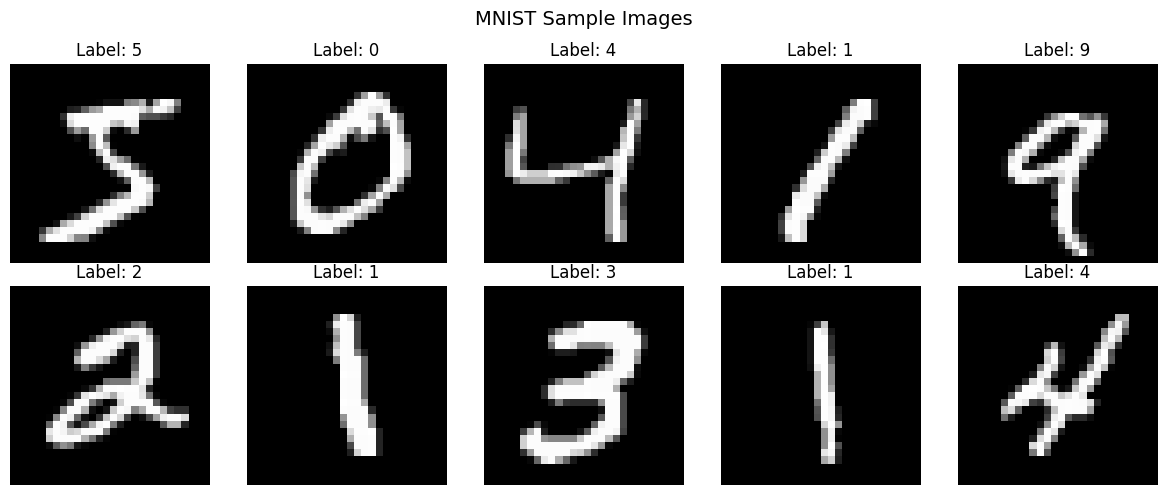

In [3]:
# 샘플 이미지 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=12)
    ax.axis('off')

plt.suptitle('MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

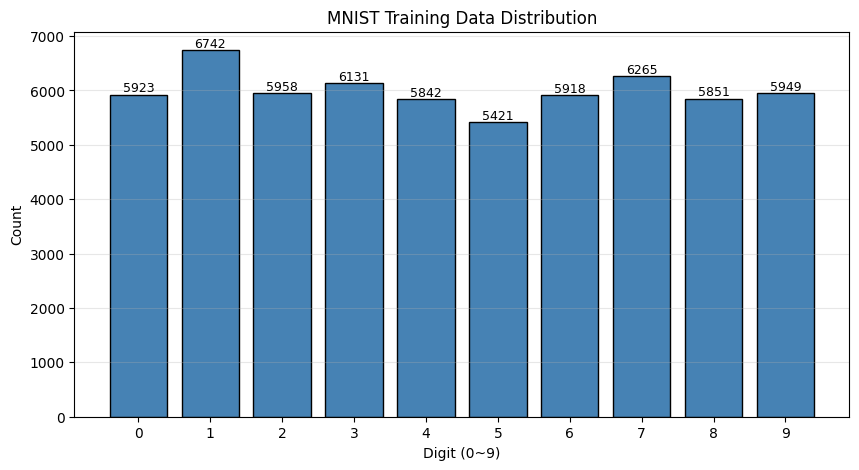

In [4]:
# 클래스별 데이터 분포 확인
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.xlabel('Digit (0~9)')
plt.ylabel('Count')
plt.title('MNIST Training Data Distribution')
plt.xticks(unique)
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(u, c + 50, str(c), ha='center', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.show()

---
## 2. 데이터 전처리

### DataLoader 만들기

DataLoader는 데이터를 **미니배치(mini-batch)** 단위로 나눠주는 도구입니다.

- **배치 크기(batch_size)**: 한 번에 모델에 넣는 데이터 수
- **셔플(shuffle)**: 매 에폭마다 데이터 순서를 섞어 학습 편향 방지

In [5]:
# DataLoader 생성
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 한 배치 확인
images, labels = next(iter(train_loader))
print(f"배치 이미지 shape: {images.shape}")   # [64, 1, 28, 28]
print(f"배치 레이블 shape: {labels.shape}")   # [64]
print(f"\n한 배치에 {batch_size}개의 이미지가 들어있습니다.")
print(f"총 배치 수: {len(train_loader)}개 (60000 / {batch_size} ≈ {len(train_loader)})")

배치 이미지 shape: torch.Size([64, 1, 28, 28])
배치 레이블 shape: torch.Size([64])

한 배치에 64개의 이미지가 들어있습니다.
총 배치 수: 938개 (60000 / 64 ≈ 938)


원본 shape: torch.Size([1, 28, 28])
Flatten 후 shape: torch.Size([784])


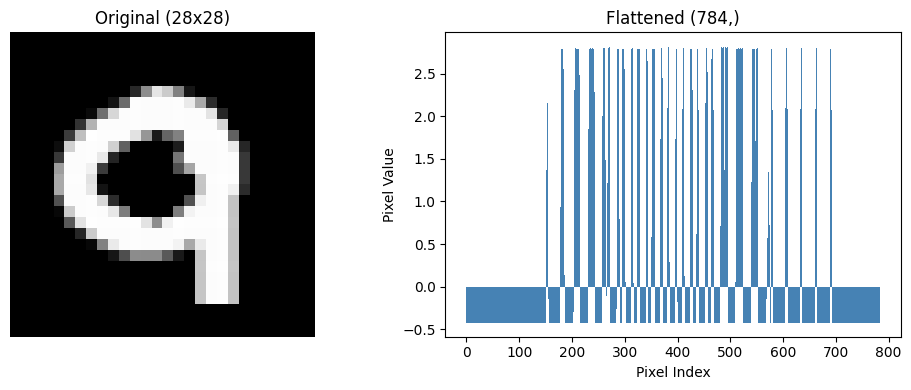

In [6]:
# 이미지를 1차원으로 펼치기 (MLP 입력용)
# 28 x 28 = 784개의 픽셀 → 784차원 벡터
sample_image = images[0]  # [1, 28, 28]
flattened = sample_image.view(-1)  # [784]

print(f"원본 shape: {sample_image.shape}")
print(f"Flatten 후 shape: {flattened.shape}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(sample_image.squeeze(), cmap='gray')
axes[0].set_title('Original (28x28)')
axes[0].axis('off')

axes[1].bar(range(784), flattened.numpy(), color='steelblue', width=1)
axes[1].set_title('Flattened (784,)')
axes[1].set_xlabel('Pixel Index')
axes[1].set_ylabel('Pixel Value')

plt.tight_layout()
plt.show()

---
## 3. MLP 모델 설계

### 모델 구조

```
입력 (784) → 은닉층1 (256) → ReLU → 은닉층2 (128) → ReLU → 출력 (10)
```

- **입력층**: 784 (= 28 x 28 픽셀)
- **은닉층 1**: 256개 뉴런 + ReLU
- **은닉층 2**: 128개 뉴런 + ReLU
- **출력층**: 10개 뉴런 (0~9 각 숫자에 대한 점수)

In [7]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.flatten = nn.Flatten()             # 28x28 → 784
        self.fc1 = nn.Linear(784, 256)          # 입력 → 은닉층1
        self.fc2 = nn.Linear(256, 128)          # 은닉층1 → 은닉층2
        self.fc3 = nn.Linear(128, 10)           # 은닉층2 → 출력
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)        # [batch, 1, 28, 28] → [batch, 784]
        x = self.relu(self.fc1(x)) # 은닉층 1
        x = self.relu(self.fc2(x)) # 은닉층 2
        x = self.fc3(x)            # 출력층 (Softmax는 CrossEntropyLoss에 포함)
        return x

model = MNISTClassifier().to(device)
print(model)

MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [8]:
# 모델 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"총 파라미터 수: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")
print()

# 레이어별 파라미터 수
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape} → {param.numel():,}개")

총 파라미터 수: 235,146
학습 가능 파라미터: 235,146

  fc1.weight: torch.Size([256, 784]) → 200,704개
  fc1.bias: torch.Size([256]) → 256개
  fc2.weight: torch.Size([128, 256]) → 32,768개
  fc2.bias: torch.Size([128]) → 128개
  fc3.weight: torch.Size([10, 128]) → 1,280개
  fc3.bias: torch.Size([10]) → 10개


---
## 4. 학습 루프 구현

2일차에서 배운 학습 루프를 그대로 적용합니다.

```python
for epoch in range(epochs):
    for images, labels in train_loader:     # 미니배치 반복
        prediction = model(images)            # 1. 순전파
        loss = criterion(prediction, labels)  # 2. 손실 계산
        optimizer.zero_grad()                 # 3. 기울기 초기화
        loss.backward()                       # 4. 역전파
        optimizer.step()                      # 5. 가중치 업데이트
```

In [9]:
# 손실함수 & 옵티마이저 설정
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 → CrossEntropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"손실함수: {criterion}")
print(f"옵티마이저: Adam (lr=0.001)")

손실함수: CrossEntropyLoss()
옵티마이저: Adam (lr=0.001)


In [10]:
# 학습 함수
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. 순전파
        outputs = model(images)

        # 2. 손실 계산
        loss = criterion(outputs, labels)

        # 3. 기울기 초기화
        optimizer.zero_grad()

        # 4. 역전파
        loss.backward()

        # 5. 가중치 업데이트
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total * 100
    return avg_loss, accuracy

In [11]:
# 평가 함수
def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # 평가 시에는 기울기 계산 불필요
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total * 100
    return avg_loss, accuracy

In [12]:
# 학습 실행
epochs = 10
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("학습 시작!")
print("=" * 70)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1:2d}/{epochs}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.2f}%")

print("=" * 70)
print(f"최종 테스트 정확도: {test_accs[-1]:.2f}%")

학습 시작!
Epoch [ 1/10]  Train Loss: 0.2327  Train Acc: 93.00%  |  Test Loss: 0.1046  Test Acc: 96.60%
Epoch [ 2/10]  Train Loss: 0.0948  Train Acc: 97.02%  |  Test Loss: 0.0761  Test Acc: 97.62%
Epoch [ 3/10]  Train Loss: 0.0652  Train Acc: 97.96%  |  Test Loss: 0.0874  Test Acc: 97.12%
Epoch [ 4/10]  Train Loss: 0.0512  Train Acc: 98.30%  |  Test Loss: 0.0745  Test Acc: 97.89%
Epoch [ 5/10]  Train Loss: 0.0385  Train Acc: 98.76%  |  Test Loss: 0.0844  Test Acc: 97.56%
Epoch [ 6/10]  Train Loss: 0.0318  Train Acc: 98.95%  |  Test Loss: 0.0712  Test Acc: 98.03%
Epoch [ 7/10]  Train Loss: 0.0308  Train Acc: 98.96%  |  Test Loss: 0.0804  Test Acc: 97.88%
Epoch [ 8/10]  Train Loss: 0.0254  Train Acc: 99.15%  |  Test Loss: 0.0942  Test Acc: 97.69%
Epoch [ 9/10]  Train Loss: 0.0210  Train Acc: 99.32%  |  Test Loss: 0.1036  Test Acc: 97.30%
Epoch [10/10]  Train Loss: 0.0212  Train Acc: 99.27%  |  Test Loss: 0.0984  Test Acc: 97.73%
최종 테스트 정확도: 97.73%


---
## 5. 모델 평가 및 시각화

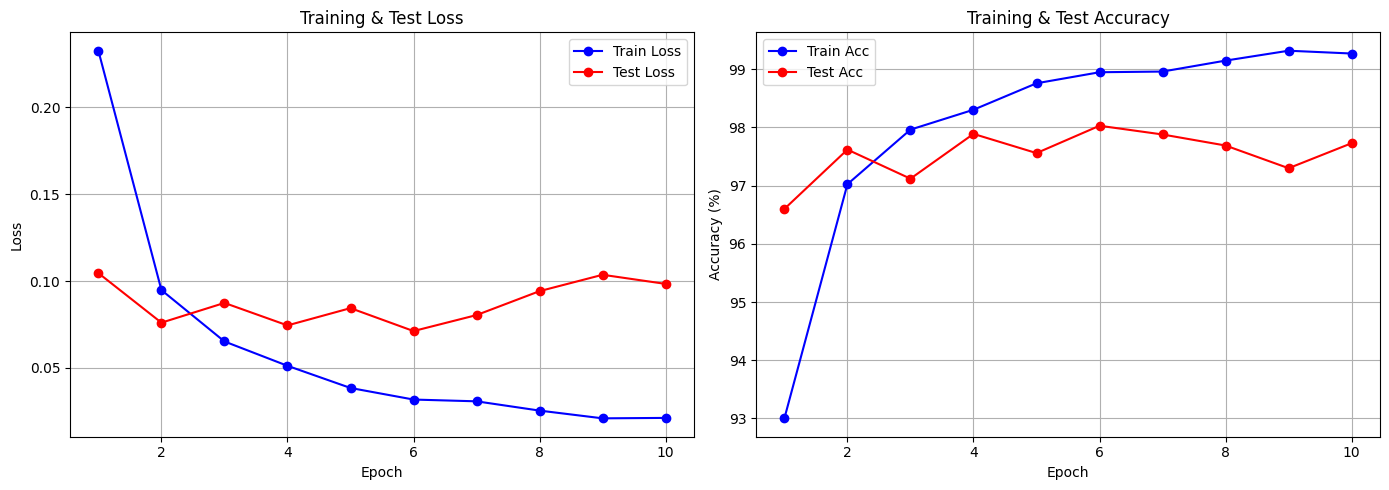

In [13]:
# 학습 과정 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(range(1, epochs+1), train_losses, 'b-o', label='Train Loss')
axes[0].plot(range(1, epochs+1), test_losses, 'r-o', label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(range(1, epochs+1), train_accs, 'b-o', label='Train Acc')
axes[1].plot(range(1, epochs+1), test_accs, 'r-o', label='Test Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Test Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

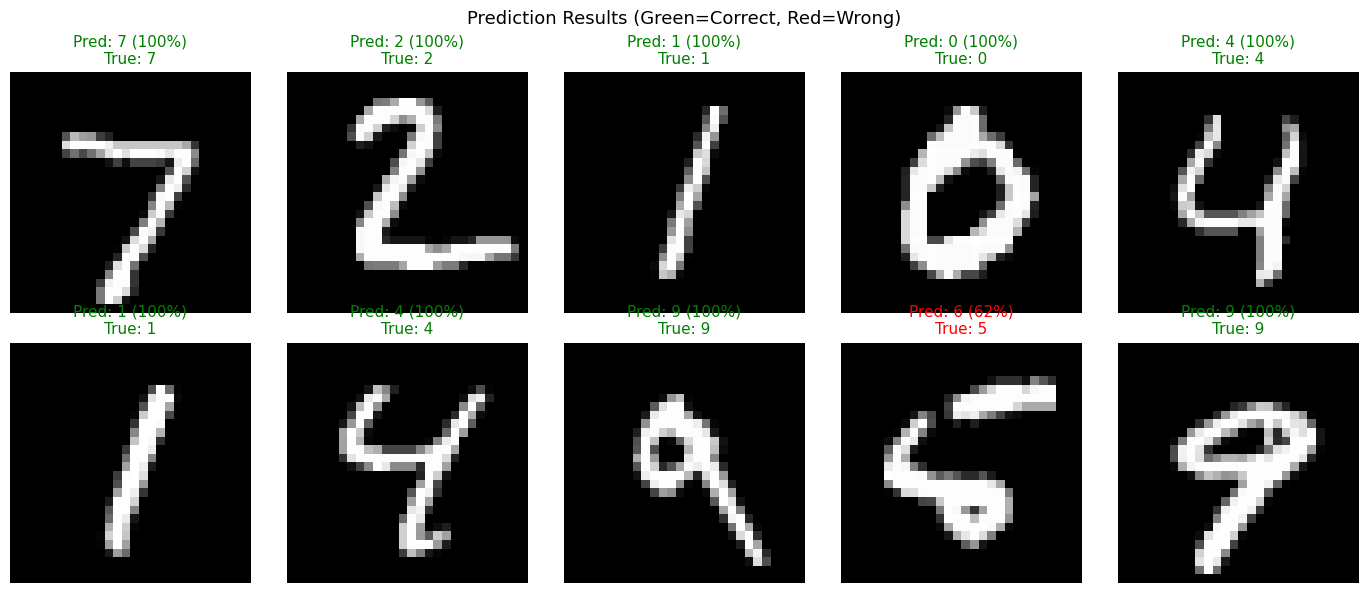

In [14]:
# 예측 결과 시각화
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    _, predicted = outputs.max(1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze()
    pred = predicted[i].item()
    true = labels[i].item()
    prob = probs[i][pred].item() * 100

    ax.imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Pred: {pred} ({prob:.0f}%)\nTrue: {true}', color=color, fontsize=11)
    ax.axis('off')

plt.suptitle('Prediction Results (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

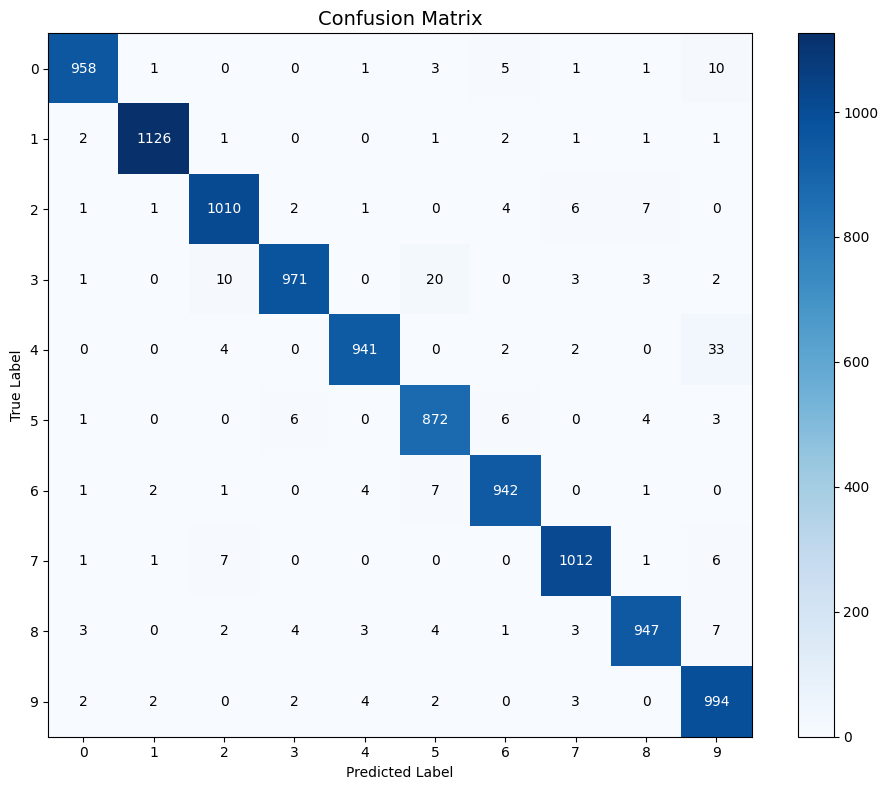

클래스별 정확도:
------------------------------
  숫자 0: 97.8% (958/980)
  숫자 1: 99.2% (1126/1135)
  숫자 2: 97.9% (1010/1032)
  숫자 3: 96.1% (971/1010)
  숫자 4: 95.8% (941/982)
  숫자 5: 97.8% (872/892)
  숫자 6: 98.3% (942/958)
  숫자 7: 98.4% (1012/1028)
  숫자 8: 97.2% (947/974)
  숫자 9: 98.5% (994/1009)


In [15]:
# 혼동 행렬 (Confusion Matrix)
from sklearn.metrics import confusion_matrix
import itertools

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.colorbar()

classes = list(range(10))
plt.xticks(classes, classes)
plt.yticks(classes, classes)

# 숫자 표시
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha='center', va='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 클래스별 정확도
print("클래스별 정확도:")
print("-" * 30)
for i in range(10):
    acc = cm[i, i] / cm[i].sum() * 100
    print(f"  숫자 {i}: {acc:.1f}% ({cm[i, i]}/{cm[i].sum()})")

총 오답 수: 227개 / 10000개
오답률: 2.27%


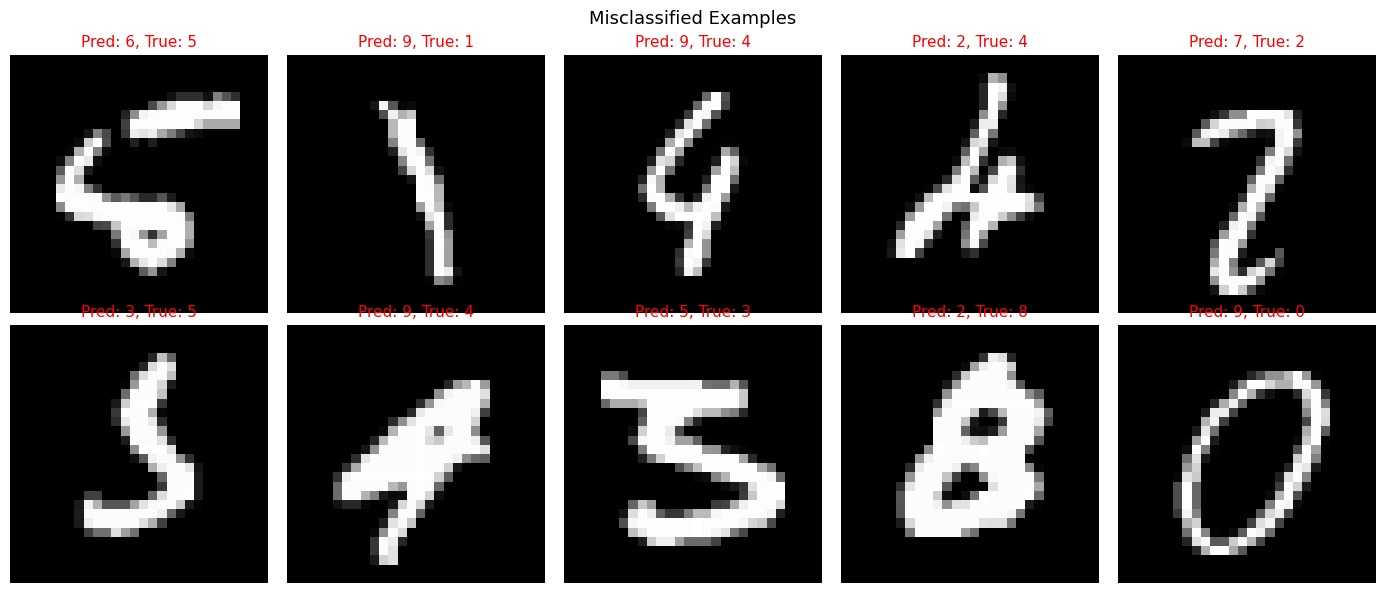

In [16]:
# 틀린 예측 분석
wrong_indices = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]
print(f"총 오답 수: {len(wrong_indices)}개 / {len(all_labels)}개")
print(f"오답률: {len(wrong_indices) / len(all_labels) * 100:.2f}%")

# 틀린 예시 시각화
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    if i >= len(wrong_indices):
        break
    idx = wrong_indices[i]
    image, true_label = test_dataset[idx]
    pred_label = all_preds[idx]

    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Pred: {pred_label}, True: {true_label}', color='red', fontsize=11)
    ax.axis('off')

plt.suptitle('Misclassified Examples', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. 모델 구조 변경 실험

은닉층 크기와 개수를 바꾸면 성능이 어떻게 달라질까요?

In [17]:
# 다양한 모델 구조 비교
class FlexibleMLP(nn.Module):
    def __init__(self, hidden_sizes):
        super(FlexibleMLP, self).__init__()
        layers = []
        input_size = 784

        for h in hidden_sizes:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h

        layers.append(nn.Linear(input_size, 10))
        self.network = nn.Sequential(nn.Flatten(), *layers)

    def forward(self, x):
        return self.network(x)


# 실험할 구조들
configs = {
    'Small (64)': [64],
    'Medium (256, 128)': [256, 128],
    'Large (512, 256, 128)': [512, 256, 128],
}

results = {}

for name, hidden in configs.items():
    torch.manual_seed(42)
    exp_model = FlexibleMLP(hidden).to(device)
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=0.001)

    params = sum(p.numel() for p in exp_model.parameters())
    print(f"\n{name} - 파라미터: {params:,}개")

    exp_losses = []
    for epoch in range(5):  # 5 에폭만
        train_loss, train_acc = train_one_epoch(exp_model, train_loader, criterion, exp_optimizer, device)
        test_loss, test_acc = evaluate(exp_model, test_loader, criterion, device)
        exp_losses.append(test_loss)
        print(f"  Epoch {epoch+1}: Test Acc = {test_acc:.2f}%")

    results[name] = {'losses': exp_losses, 'final_acc': test_acc, 'params': params}


Small (64) - 파라미터: 50,890개
  Epoch 1: Test Acc = 95.47%
  Epoch 2: Test Acc = 96.35%
  Epoch 3: Test Acc = 96.93%
  Epoch 4: Test Acc = 97.09%
  Epoch 5: Test Acc = 97.35%

Medium (256, 128) - 파라미터: 235,146개
  Epoch 1: Test Acc = 96.74%
  Epoch 2: Test Acc = 97.29%
  Epoch 3: Test Acc = 97.21%
  Epoch 4: Test Acc = 97.62%
  Epoch 5: Test Acc = 97.59%

Large (512, 256, 128) - 파라미터: 567,434개
  Epoch 1: Test Acc = 96.17%
  Epoch 2: Test Acc = 96.66%
  Epoch 3: Test Acc = 97.05%
  Epoch 4: Test Acc = 97.51%
  Epoch 5: Test Acc = 97.86%


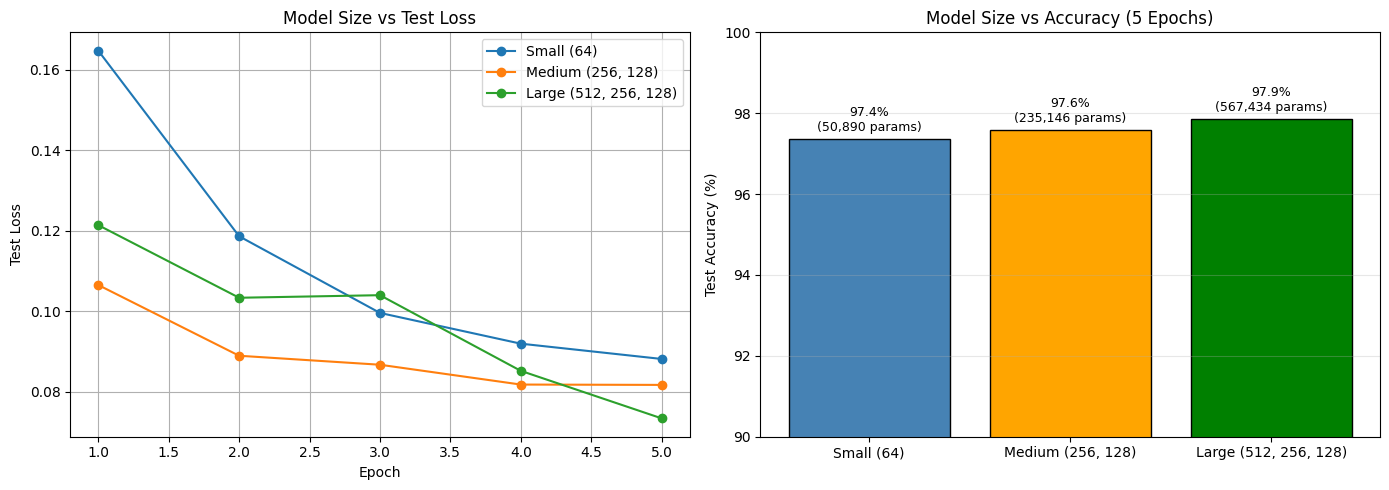

In [18]:
# 결과 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Loss 비교
for name, res in results.items():
    axes[0].plot(range(1, 6), res['losses'], '-o', label=name)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Loss')
axes[0].set_title('Model Size vs Test Loss')
axes[0].legend()
axes[0].grid(True)

# 파라미터 수 vs 정확도
names = list(results.keys())
params = [results[n]['params'] for n in names]
accs = [results[n]['final_acc'] for n in names]

axes[1].bar(names, accs, color=['steelblue', 'orange', 'green'], edgecolor='black')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Model Size vs Accuracy (5 Epochs)')
for i, (p, a) in enumerate(zip(params, accs)):
    axes[1].text(i, a + 0.2, f'{a:.1f}%\n({p:,} params)', ha='center', fontsize=9)
axes[1].set_ylim(90, 100)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 정리

이번 실습에서 배운 내용:

1. **MNIST 데이터셋**: 28x28 흑백 손글씨 이미지 70,000장
2. **DataLoader**: 데이터를 미니배치로 나눠서 효율적으로 학습
3. **MLP 모델**: `nn.Module`을 상속하여 784 → 256 → 128 → 10 구조 설계
4. **학습 루프**: 순전파 → CrossEntropyLoss → zero_grad → backward → step
5. **평가**: 혼동 행렬, 클래스별 정확도, 오답 분석
6. **모델 구조 실험**: 은닉층 크기에 따른 성능 변화 확인

### 핵심 코드
```python
# 모델 정의
model = MNISTClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 루프
for epoch in range(epochs):
    for images, labels in train_loader:
        outputs = model(images)              # 순전파
        loss = criterion(outputs, labels)     # 손실 계산
        optimizer.zero_grad()                 # 기울기 초기화
        loss.backward()                       # 역전파
        optimizer.step()                      # 가중치 업데이트
```

### 다음 시간
3일차에서는 **과적합(Overfitting)** 문제와 이를 해결하는 정규화 기법을 배웁니다!